## Dados referentes a anúncios de vendas de carros ##

In [ ]:
# importando bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'vscode'

In [ ]:
# dados
df = pd.read_csv("https://raw.githubusercontent.com/b-brito/tripleten/refs/heads/main/vehicles_us.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB


In [ ]:
# remove colunas não utilizadas na análise
df = df.drop(columns=['cylinders', 'is_4wd', 'date_posted'])

In [ ]:
# remove valores nulos não utilizados na análise
df = df.dropna()

In [17]:
# altera o tipo de dados para int
df['model_year'] = df['model_year'].astype(int)

In [ ]:
# obtém a marca do carro a partir da coluna 'modelo' que segue o padrão: marca + modelo
df['brand'] = df['model'].str.split().str[0]
df['brand'] = df['brand'].str.lower()

In [137]:
df.head()

,price,model_year,model,condition,fuel,odometer,transmission,type,paint_color,days_listed,brand
2,5500,2013,hyundai sonata,like new,gas,110000.0,automatic,sedan,red,79,hyundai
4,14900,2017,chrysler 200,excellent,gas,80903.0,automatic,sedan,black,28,chrysler
5,14990,2014,chrysler 300,excellent,gas,57954.0,automatic,sedan,black,15,chrysler
6,12990,2015,toyota camry,excellent,gas,79212.0,automatic,sedan,white,73,toyota
7,15990,2013,honda pilot,excellent,gas,109473.0,automatic,SUV,black,68,honda


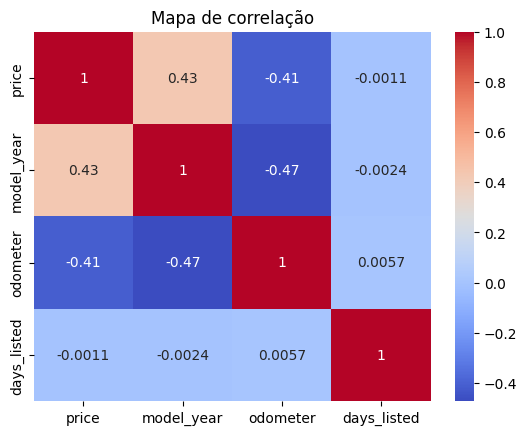

In [105]:
# correlação entre variáveis numéricas
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Mapa de correlação')
plt.show()

Correlação positiva (0.43) entre `price` e `model_year`. É uma correlação fraca-moderada, mas sugere que carros novos tendem a ser mais caros.<br>

Correlação negativa (-0.47) entre `odometer` e `model_year`. É uma correlação fraca-moderada, mas sugere que carros novos tenham menor quilometragem.<br>

Correlação negativa (-0.41) entre `odometer` e `price`. É uma correlação fraca-moderada, mas sugere que o preço diminui conforme a quilometragem aumenta.<br>

A variável `days_listed` não se correlacionou com as demais variáveis, o que pode sugerir que o tempo de venda dependa de outras variáveis qualitativas, tais como a marca, a condição do carro ou o tipo de combustível, por exemplo, entre outras.

In [ ]:
# gráfico de dispersão entre preço e ano do modelo
fig = px.scatter(df, x='model_year', y='price', title='Preço x Ano')
fig.update_layout(xaxis_title='Ano do modelo', yaxis_title='Preço (US$)')
fig.show(renderer='vscode')

In [ ]:
# gráfico de dispersão entre odômetro e ano do modelo
fig = px.scatter(df, x='model_year', y='odometer', title='Odômetro x Ano')
fig.update_layout(xaxis_title='Ano do modelo', yaxis_title='Odômetro (km)')
fig.show(renderer='vscode')

Apesar de existir correlação negativa, ela é fraca-moderada. É difícil percebê-la visualmente porque alguns carros antigos foram pouco utilizados (baixo odômetro) e alguns carros recentes já rodaram bastante.<br>

Há concentração de pontos nos anos após `2000`, e dentro desse intervalo há uma leve tendência de redução de odômetro conforme o ano aumenta, reforçando o sentido negativo da correlação.

In [ ]:
# gráfico de dispersão entre odômetro e preço
fig = px.scatter(df, x='odometer', y='price', title='Preço x Odômetro')
fig.update_layout(xaxis_title='Odômetro (km)', yaxis_title='Preço (US$)')
fig.show(renderer='vscode')

In [ ]:
# histograma de quilometragem
fig = px.histogram(df, x='odometer', title='Distribuição de quilometragem dos veículos')
fig.update_layout(xaxis_title='Odômetro (km)', yaxis_title='Contagem')
fig.show(renderer='vscode')

Alguns carros têm alto valor de quilometragem, mas a maior concentração encontra-se em torno de `100.000 km`. 

In [ ]:
# histograma de quilometragem por tipo de combustível (gráfico sobreposto)
fig = px.histogram(df, x='odometer', color='fuel', opacity=0.5, title='Distribuição de quilometragem por tipo de combustível')
fig.update_layout(barmode="overlay")
fig.update_layout(xaxis_title='Odômetro (km)', yaxis_title='Contagem')
fig.show(renderer='vscode')

O consumo de `gas` (gasolina) é majoritariamente maior e predomina perante os demais combustíveis.

In [ ]:
# filtra top 10 marcas
# filtra top 4 tipos de carros

top_brands = df['brand'].value_counts().sort_values(ascending=False).head(10).index
top_types = df['type'].value_counts().sort_values(ascending=False).head(4).index

# cria o DataFrame filtrado

df_filtrado = df[df['brand'].isin(top_brands)]
df_filtrado = df_filtrado[df_filtrado['type'].isin(top_types)]

In [ ]:
# ordem crescente de marca por valor de mediana
ordem_marcas = df_filtrado.groupby('brand')['price'].median().sort_values(ascending=True)
ordem_m = []
for marca in ordem_marcas.index:
    ordem_m.append(marca)

In [154]:
# boxplot de preço para as top 10 marcas de veículos (ordem mediana menor > maior)
fig = px.box(
    df_filtrado,
    x='brand',
    y='price',
    color='brand',
    points='outliers',
    title='Preço (US$) por marca',
    category_orders={'brand': ordem_m}
)
fig.update_layout(xaxis_title='Marca', yaxis_title='Preço (US$)')
fig.show(renderer='vscode')

O eixo X do gráfico está ordenado pela progressão do valor da mediana do preço dos veículos oferecidos por marca.<br>

As marcas `GMC` e `Ram` apresentam maiores valores de mediana. No próximo boxplot, nota-se a comparação de preço por tipo de veículo e que `pickup` e `truck` são os tipos mais caros, o que justifica a posição destas duas marcas neste gráfico.<br>

Mesmo assim, todas as marcas apresentam outliers, o que é esperado para dados referentes a carros novos e usados, e reflete variações naturais entre versões e modelos da mesma marca.

In [ ]:
# ordem crescente de tipo de veículo por valor de mediana
ordem_tipo = df_filtrado.groupby('type')['price'].median().sort_values(ascending=True)
ordem_t = []
for tipo in ordem_tipo.index:
    ordem_t.append(tipo)

In [158]:
# boxplot de preço para os top 4 tipos de veículos
fig = px.box(
    df_filtrado,
    x='type',
    y='price',
    color='type',
    points='outliers',
    title='Preço (US$) por tipo de veículo',
    category_orders={'type': ordem_t}
)
fig.update_layout(xaxis_title='Tipo de veículo', yaxis_title='Preço (US$)')
fig.show(renderer='vscode')

A categoria `truck` possui outliers mais altos, indicando a existência de modelos muito caros. Junto da categoria `pickup`, que também possui outliers altos, as duas categorias apresentam amplitude interquartil maior, sugerindo distribuições mais dispersas com maior diversidade de modelos e faixas de preços.<br>

Enquanto isso, `sedan` e `SUV` possuem amplitude interquartil menor, com preços mais concentrados.<br>

É possível notar que a linha da mediana dentro do boxplot cresce levemente desde `sedan`, `SUV`, `pickup` até `truck`, mostrando a progreção de preço entre esses tipos de veículos.